# Metaheuristic Optimisation for IDS Feature Selection & Hyperparameter Tuning
## COMP2024 Coursework

This notebook implements four metaheuristic algorithms — **Genetic Algorithm (GA)**, **Particle Swarm Optimisation (PSO)**, **Ant Colony Optimisation (ACO)**, and a **Hybrid GA-PSO** — for simultaneous feature selection and hyperparameter tuning of an XGBoost-based Intrusion Detection System.

Each algorithm optimises:
- **Feature subset** (binary mask over 45 features)
- **Hyperparameters**: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`

A **shared fitness function** is used across all four methods for fair comparison.

---
## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import time
import os
import joblib
import warnings
import copy
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = './Dataset_Cleaned/'
OUTPUT_DIR = './outputs/metaheuristic/'
SEED       = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(SEED)

print("Configuration loaded.")
print(f"  Output directory : {OUTPUT_DIR}")
print(f"  Random seed      : {SEED}")

Configuration loaded.
  Output directory : ./outputs/metaheuristic/
  Random seed      : 42


---
## 2. Load Data & Create 10% Optimisation Subset

To keep runtime practical on a local machine, we use a **stratified 10% sample** of the SMOTE-balanced training data for fitness evaluation during optimisation. The **full test set** is used for final evaluation only.

In [2]:
from sklearn.model_selection import train_test_split

print("Loading datasets...")

X_train_full = pd.read_csv(DATA_DIR + 'X_train_smote.csv')
y_train_full = pd.read_csv(DATA_DIR + 'y_train_smote.csv').squeeze()
X_test       = pd.read_csv(DATA_DIR + 'X_test.csv')
y_test       = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()

feature_names = X_train_full.columns.tolist()
n_features    = len(feature_names)

print(f"  Full training set : {X_train_full.shape}")
print(f"  Test set          : {X_test.shape}")
print(f"  Features          : {n_features}")

# ── 10% stratified sample for optimisation ─────────────────────────────────
SAMPLE_FRAC = 0.10

X_opt, _, y_opt, _ = train_test_split(
    X_train_full, y_train_full,
    train_size    = SAMPLE_FRAC,
    random_state  = SEED,
    stratify      = y_train_full
)

X_opt = X_opt.values  # convert to numpy for speed
y_opt = y_opt.values
X_test_np  = X_test.values
y_test_np  = y_test.values

print(f"\n  Optimisation subset (10%) : {X_opt.shape}")
print(f"  Class balance: 0={np.sum(y_opt==0):,}  |  1={np.sum(y_opt==1):,}")

Loading datasets...
  Full training set : (3354374, 45)
  Test set          : (504473, 45)
  Features          : 45

  Optimisation subset (10%) : (335437, 45)
  Class balance: 0=167,718  |  1=167,719


---
## 3. Shared Fitness Function

All three metaheuristics use the **same fitness function** for a fair comparison.

**Solution encoding** (length = 45 + 5 = 50):
- Positions `[0:45]` — binary feature mask (1 = selected, 0 = excluded)
- Position `[45]` — `n_estimators` (mapped to 50–500)
- Position `[46]` — `max_depth` (mapped to 3–12)
- Position `[47]` — `learning_rate` (mapped to 0.01–0.3)
- Position `[48]` — `subsample` (mapped to 0.5–1.0)
- Position `[49]` — `colsample_bytree` (mapped to 0.5–1.0)

**Fitness** = `F1_weighted` — a small penalty for using many features, encouraging parsimony.

$$\text{fitness} = F1_{weighted} - \alpha \cdot \frac{\text{features selected}}{\text{total features}}$$

where $\alpha = 0.01$ is a small penalty weight.

In [3]:
# ── Hyperparameter bounds ────────────────────────────────────────────────────
HP_BOUNDS = {
    'n_estimators':     (50, 500),
    'max_depth':        (3, 12),
    'learning_rate':    (0.01, 0.3),
    'subsample':        (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0)
}

ALPHA = 0.01  # feature penalty weight
SOLUTION_DIM = n_features + len(HP_BOUNDS)  # 45 + 5 = 50


def decode_solution(solution):
    """
    Decode a continuous solution vector into a feature mask and hyperparameters.
    - Positions [0:n_features]: values > 0.5 → feature selected
    - Positions [n_features:]:  continuous values mapped to HP ranges
    """
    # Feature mask: threshold at 0.5
    feat_mask = (solution[:n_features] > 0.5).astype(int)

    # Ensure at least 3 features are selected
    if feat_mask.sum() < 3:
        top_idx = np.argsort(solution[:n_features])[-3:]
        feat_mask[top_idx] = 1

    # Decode hyperparameters (clamp continuous values to [0, 1] then scale)
    hp_vals = np.clip(solution[n_features:], 0.0, 1.0)

    hp = {
        'n_estimators':     int(hp_vals[0] * (500 - 50) + 50),
        'max_depth':        int(hp_vals[1] * (12 - 3) + 3),
        'learning_rate':    hp_vals[2] * (0.3 - 0.01) + 0.01,
        'subsample':        hp_vals[3] * (1.0 - 0.5) + 0.5,
        'colsample_bytree': hp_vals[4] * (1.0 - 0.5) + 0.5
    }

    return feat_mask, hp


def fitness_function(solution, X_data, y_data):
    """
    Evaluate a solution using 3-fold stratified cross-validation on the
    optimisation subset.  Returns fitness score (higher is better).
    """
    feat_mask, hp = decode_solution(solution)
    selected_idx = np.where(feat_mask == 1)[0]

    X_sel = X_data[:, selected_idx]

    model = XGBClassifier(
        n_estimators     = hp['n_estimators'],
        max_depth        = hp['max_depth'],
        learning_rate    = hp['learning_rate'],
        subsample        = hp['subsample'],
        colsample_bytree = hp['colsample_bytree'],
        objective        = 'binary:logistic',
        eval_metric      = 'logloss',
        tree_method      = 'hist',
        n_jobs           = -1,
        random_state     = SEED,
        verbosity        = 0
    )

    # 3-fold CV for robust fitness estimate
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    f1_scores = []

    for train_idx, val_idx in skf.split(X_sel, y_data):
        model.fit(X_sel[train_idx], y_data[train_idx], verbose=False)
        y_pred = model.predict(X_sel[val_idx])
        f1_scores.append(f1_score(y_data[val_idx], y_pred, average='weighted', zero_division=0))

    avg_f1 = np.mean(f1_scores)

    # Parsimony penalty: slight cost for using more features
    feat_ratio = len(selected_idx) / n_features
    fitness = avg_f1 - ALPHA * feat_ratio

    return fitness


print(f"Solution dimension : {SOLUTION_DIM}")
print(f"Feature dimensions : {n_features}")
print(f"HP dimensions      : {len(HP_BOUNDS)}")
print(f"Parsimony penalty  : alpha = {ALPHA}")
print("Fitness function ready.")

Solution dimension : 50
Feature dimensions : 45
HP dimensions      : 5
Parsimony penalty  : alpha = 0.01
Fitness function ready.


---
## 4. Genetic Algorithm (GA)

A population-based search inspired by natural selection. Solutions evolve through:
- **Tournament selection** (selects fitter parents)
- **Uniform crossover** (combines parent solutions)
- **Gaussian mutation** (explores nearby solutions)

The GA searches the combined feature-selection and hyperparameter space simultaneously.

In [4]:
def genetic_algorithm(X_data, y_data, pop_size=20, n_generations=30,
                      crossover_rate=0.8, mutation_rate=0.1,
                      tournament_size=3, elitism=2):
    """
    Genetic Algorithm for feature selection and hyperparameter tuning.

    Parameters
    ----------
    pop_size        : int   — number of individuals in the population
    n_generations   : int   — number of evolutionary generations
    crossover_rate  : float — probability of crossover between parents
    mutation_rate   : float — probability of mutating each gene
    tournament_size : int   — number of candidates in tournament selection
    elitism         : int   — number of top individuals carried forward unchanged

    Returns
    -------
    best_solution, best_fitness, convergence_history
    """
    dim = SOLUTION_DIM

    # ── Initialise population randomly in [0, 1] ─────────────────────────────
    population = np.random.rand(pop_size, dim)
    fitness_vals = np.array([fitness_function(ind, X_data, y_data) for ind in population])

    best_idx = np.argmax(fitness_vals)
    global_best = population[best_idx].copy()
    global_best_fit = fitness_vals[best_idx]

    convergence = [global_best_fit]

    print(f"  GA — Gen 0: Best Fitness = {global_best_fit:.6f}")

    for gen in range(1, n_generations + 1):
        new_population = []

        # ── Elitism: keep top individuals ────────────────────────────────────
        elite_idx = np.argsort(fitness_vals)[-elitism:]
        for idx in elite_idx:
            new_population.append(population[idx].copy())

        # ── Fill rest of population ──────────────────────────────────────────
        while len(new_population) < pop_size:
            # Tournament selection for two parents
            def tournament():
                candidates = np.random.choice(pop_size, tournament_size, replace=False)
                winner = candidates[np.argmax(fitness_vals[candidates])]
                return population[winner].copy()

            parent1 = tournament()
            parent2 = tournament()

            # Uniform crossover
            if np.random.rand() < crossover_rate:
                mask = np.random.rand(dim) < 0.5
                child = np.where(mask, parent1, parent2)
            else:
                child = parent1.copy()

            # Gaussian mutation
            for j in range(dim):
                if np.random.rand() < mutation_rate:
                    child[j] += np.random.normal(0, 0.1)
                    child[j] = np.clip(child[j], 0.0, 1.0)

            new_population.append(child)

        population = np.array(new_population[:pop_size])
        fitness_vals = np.array([fitness_function(ind, X_data, y_data) for ind in population])

        best_idx = np.argmax(fitness_vals)
        if fitness_vals[best_idx] > global_best_fit:
            global_best = population[best_idx].copy()
            global_best_fit = fitness_vals[best_idx]

        convergence.append(global_best_fit)

        if gen % 5 == 0 or gen == n_generations:
            feat_count = (decode_solution(global_best)[0]).sum()
            print(f"  GA — Gen {gen:>3d}: Best Fitness = {global_best_fit:.6f}  "
                  f"| Features = {feat_count} | Pop Avg = {fitness_vals.mean():.6f}")

    return global_best, global_best_fit, convergence


print("Genetic Algorithm function defined.")

Genetic Algorithm function defined.


In [5]:
# ── Run GA ────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  Running Genetic Algorithm")
print("=" * 60)

ga_start = time.time()
ga_best_sol, ga_best_fit, ga_convergence = genetic_algorithm(
    X_opt, y_opt,
    pop_size       = 20,
    n_generations  = 30,
    crossover_rate = 0.8,
    mutation_rate  = 0.1,
    tournament_size = 3,
    elitism        = 2
)
ga_time = time.time() - ga_start

ga_feat_mask, ga_hp = decode_solution(ga_best_sol)
ga_selected_features = [feature_names[i] for i in range(n_features) if ga_feat_mask[i] == 1]

print(f"\n  GA completed in {ga_time:.1f}s")
print(f"  Best fitness     : {ga_best_fit:.6f}")
print(f"  Features selected: {len(ga_selected_features)}/{n_features}")
print(f"  Hyperparameters  : {ga_hp}")
print(f"  Selected features: {ga_selected_features}")

  Running Genetic Algorithm
  GA — Gen 0: Best Fitness = 0.994103
  GA — Gen   5: Best Fitness = 0.995543  | Features = 13 | Pop Avg = 0.995095
  GA — Gen  10: Best Fitness = 0.996441  | Features = 7 | Pop Avg = 0.996151
  GA — Gen  15: Best Fitness = 0.996800  | Features = 8 | Pop Avg = 0.996673
  GA — Gen  20: Best Fitness = 0.996876  | Features = 9 | Pop Avg = 0.996736
  GA — Gen  25: Best Fitness = 0.997040  | Features = 7 | Pop Avg = 0.996823
  GA — Gen  30: Best Fitness = 0.997203  | Features = 8 | Pop Avg = 0.996993

  GA completed in 1626.5s
  Best fitness     : 0.997203
  Features selected: 8/45
  Hyperparameters  : {'n_estimators': 247, 'max_depth': 8, 'learning_rate': np.float64(0.256031783986252), 'subsample': np.float64(0.6255517025561016), 'colsample_bytree': np.float64(0.836836839431681)}
  Selected features: ['Destination Port', 'Bwd Packet Length Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Min', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forw

---
## 5. Particle Swarm Optimisation (PSO)

A swarm-intelligence method where particles explore the search space by adjusting their velocity based on:
- **Personal best** (cognitive component) — the best position each particle has found
- **Global best** (social component) — the best position found by any particle in the swarm

An **inertia weight** decays linearly from `w_max` to `w_min` over iterations to shift from exploration to exploitation.

In [6]:
def particle_swarm_optimisation(X_data, y_data, n_particles=20, n_iterations=30,
                                 w_max=0.9, w_min=0.4, c1=2.0, c2=2.0):
    """
    Particle Swarm Optimisation for feature selection and hyperparameter tuning.

    Parameters
    ----------
    n_particles  : int   — swarm size
    n_iterations : int   — number of PSO iterations
    w_max, w_min : float — inertia weight bounds (linear decay)
    c1           : float — cognitive (personal best) acceleration coefficient
    c2           : float — social (global best) acceleration coefficient

    Returns
    -------
    best_position, best_fitness, convergence_history
    """
    dim = SOLUTION_DIM

    # ── Initialise positions and velocities ──────────────────────────────────
    positions  = np.random.rand(n_particles, dim)
    velocities = np.random.uniform(-0.1, 0.1, (n_particles, dim))

    # Evaluate initial fitness
    fitness_vals = np.array([fitness_function(p, X_data, y_data) for p in positions])

    # Personal bests
    pbest_positions = positions.copy()
    pbest_fitness   = fitness_vals.copy()

    # Global best
    gbest_idx     = np.argmax(fitness_vals)
    gbest_pos     = positions[gbest_idx].copy()
    gbest_fitness = fitness_vals[gbest_idx]

    convergence = [gbest_fitness]
    print(f"  PSO — Iter 0: Best Fitness = {gbest_fitness:.6f}")

    for iteration in range(1, n_iterations + 1):
        # Linear inertia weight decay
        w = w_max - (w_max - w_min) * (iteration / n_iterations)

        for i in range(n_particles):
            r1 = np.random.rand(dim)
            r2 = np.random.rand(dim)

            # Velocity update
            velocities[i] = (w * velocities[i]
                             + c1 * r1 * (pbest_positions[i] - positions[i])
                             + c2 * r2 * (gbest_pos - positions[i]))

            # Clamp velocity
            velocities[i] = np.clip(velocities[i], -0.5, 0.5)

            # Position update
            positions[i] += velocities[i]
            positions[i] = np.clip(positions[i], 0.0, 1.0)

            # Evaluate
            fit = fitness_function(positions[i], X_data, y_data)
            fitness_vals[i] = fit

            # Update personal best
            if fit > pbest_fitness[i]:
                pbest_fitness[i]   = fit
                pbest_positions[i] = positions[i].copy()

            # Update global best
            if fit > gbest_fitness:
                gbest_fitness = fit
                gbest_pos     = positions[i].copy()

        convergence.append(gbest_fitness)

        if iteration % 5 == 0 or iteration == n_iterations:
            feat_count = (decode_solution(gbest_pos)[0]).sum()
            print(f"  PSO — Iter {iteration:>3d}: Best Fitness = {gbest_fitness:.6f}  "
                  f"| Features = {feat_count} | w = {w:.3f}")

    return gbest_pos, gbest_fitness, convergence


print("Particle Swarm Optimisation function defined.")

Particle Swarm Optimisation function defined.


In [7]:
# ── Run PSO ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("  Running Particle Swarm Optimisation")
print("=" * 60)

pso_start = time.time()
pso_best_sol, pso_best_fit, pso_convergence = particle_swarm_optimisation(
    X_opt, y_opt,
    n_particles  = 20,
    n_iterations = 30,
    w_max        = 0.9,
    w_min        = 0.4,
    c1           = 2.0,
    c2           = 2.0
)
pso_time = time.time() - pso_start

pso_feat_mask, pso_hp = decode_solution(pso_best_sol)
pso_selected_features = [feature_names[i] for i in range(n_features) if pso_feat_mask[i] == 1]

print(f"\n  PSO completed in {pso_time:.1f}s")
print(f"  Best fitness     : {pso_best_fit:.6f}")
print(f"  Features selected: {len(pso_selected_features)}/{n_features}")
print(f"  Hyperparameters  : {pso_hp}")
print(f"  Selected features: {pso_selected_features}")

  Running Particle Swarm Optimisation
  PSO — Iter 0: Best Fitness = 0.994448
  PSO — Iter   5: Best Fitness = 0.995441  | Features = 15 | w = 0.817
  PSO — Iter  10: Best Fitness = 0.995562  | Features = 14 | w = 0.733
  PSO — Iter  15: Best Fitness = 0.995586  | Features = 14 | w = 0.650
  PSO — Iter  20: Best Fitness = 0.995977  | Features = 12 | w = 0.567
  PSO — Iter  25: Best Fitness = 0.996193  | Features = 11 | w = 0.483
  PSO — Iter  30: Best Fitness = 0.996247  | Features = 11 | w = 0.400

  PSO completed in 1544.5s
  Best fitness     : 0.996247
  Features selected: 11/45
  Hyperparameters  : {'n_estimators': 324, 'max_depth': 4, 'learning_rate': np.float64(0.3), 'subsample': np.float64(1.0), 'colsample_bytree': np.float64(1.0)}
  Selected features: ['Destination Port', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd Packets/s', 'Packet Length Variance', 'RST Flag Count', 'Init_Win_bytes_forward', 'Active Mean']


---
## 6. Ant Colony Optimisation (ACO)

ACO is inspired by the foraging behaviour of ants. Ants deposit pheromone on solution components proportional to solution quality. Future ants probabilistically prefer components with higher pheromone.

**Adaptation for continuous optimisation:**
- Each dimension is discretised into `n_bins` levels.
- Pheromone is maintained per dimension per bin.
- Ants construct solutions by probabilistically selecting a bin for each dimension based on pheromone levels.
- Pheromone evaporates each iteration, and the best ant deposits extra pheromone.

In [8]:
def ant_colony_optimisation(X_data, y_data, n_ants=20, n_iterations=30,
                             n_bins=10, evaporation_rate=0.3, q=1.0):
    """
    Ant Colony Optimisation for feature selection and hyperparameter tuning.

    Uses a discretised continuous search space where pheromone is deposited
    on bins for each solution dimension.

    Parameters
    ----------
    n_ants           : int   — number of ants per iteration
    n_iterations     : int   — number of ACO iterations
    n_bins           : int   — discretisation bins per dimension
    evaporation_rate : float — pheromone evaporation rate (0–1)
    q                : float — pheromone deposit strength

    Returns
    -------
    best_solution, best_fitness, convergence_history
    """
    dim = SOLUTION_DIM

    # Bin edges: [0, 0.1, 0.2, ..., 1.0] → bin centres
    bin_edges   = np.linspace(0, 1, n_bins + 1)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2  # shape: (n_bins,)

    # Pheromone matrix: one row per dimension, one column per bin
    pheromone = np.ones((dim, n_bins))  # uniform initial pheromone

    global_best_sol = None
    global_best_fit = -np.inf
    convergence = []

    for iteration in range(n_iterations + 1):
        solutions = []
        fitness_vals = []

        for ant in range(n_ants):
            solution = np.zeros(dim)

            for d in range(dim):
                # Probability of choosing each bin is proportional to pheromone
                probs = pheromone[d] / pheromone[d].sum()
                chosen_bin = np.random.choice(n_bins, p=probs)
                # Add small noise within the bin width for exploration
                noise = np.random.uniform(-0.5/n_bins, 0.5/n_bins)
                solution[d] = np.clip(bin_centres[chosen_bin] + noise, 0.0, 1.0)

            fit = fitness_function(solution, X_data, y_data)
            solutions.append(solution)
            fitness_vals.append(fit)

        solutions = np.array(solutions)
        fitness_vals = np.array(fitness_vals)

        # Update global best
        iter_best_idx = np.argmax(fitness_vals)
        if fitness_vals[iter_best_idx] > global_best_fit:
            global_best_fit = fitness_vals[iter_best_idx]
            global_best_sol = solutions[iter_best_idx].copy()

        convergence.append(global_best_fit)

        # ── Pheromone update ──────────────────────────────────────────────────
        # Evaporation
        pheromone *= (1 - evaporation_rate)

        # Deposit pheromone: all ants deposit proportional to their fitness
        for ant in range(n_ants):
            for d in range(dim):
                # Find which bin this ant's solution falls into
                bin_idx = np.clip(int(solutions[ant, d] * n_bins), 0, n_bins - 1)
                pheromone[d, bin_idx] += q * fitness_vals[ant]

        # Extra deposit for iteration-best ant (elitist strategy)
        for d in range(dim):
            bin_idx = np.clip(int(solutions[iter_best_idx, d] * n_bins), 0, n_bins - 1)
            pheromone[d, bin_idx] += q * fitness_vals[iter_best_idx]

        # Clamp pheromone to prevent stagnation
        pheromone = np.clip(pheromone, 0.1, 50.0)

        if iteration % 5 == 0 or iteration == n_iterations:
            feat_count = (decode_solution(global_best_sol)[0]).sum()
            print(f"  ACO — Iter {iteration:>3d}: Best Fitness = {global_best_fit:.6f}  "
                  f"| Features = {feat_count} | Iter Avg = {fitness_vals.mean():.6f}")

    return global_best_sol, global_best_fit, convergence


print("Ant Colony Optimisation function defined.")

Ant Colony Optimisation function defined.


In [9]:
# ── Run ACO ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("  Running Ant Colony Optimisation")
print("=" * 60)

aco_start = time.time()
aco_best_sol, aco_best_fit, aco_convergence = ant_colony_optimisation(
    X_opt, y_opt,
    n_ants           = 20,
    n_iterations     = 30,
    n_bins           = 10,
    evaporation_rate = 0.3,
    q                = 1.0
)
aco_time = time.time() - aco_start

aco_feat_mask, aco_hp = decode_solution(aco_best_sol)
aco_selected_features = [feature_names[i] for i in range(n_features) if aco_feat_mask[i] == 1]

print(f"\n  ACO completed in {aco_time:.1f}s")
print(f"  Best fitness     : {aco_best_fit:.6f}")
print(f"  Features selected: {len(aco_selected_features)}/{n_features}")
print(f"  Hyperparameters  : {aco_hp}")
print(f"  Selected features: {aco_selected_features}")

  Running Ant Colony Optimisation
  ACO — Iter   0: Best Fitness = 0.994556  | Features = 17 | Iter Avg = 0.991374
  ACO — Iter   5: Best Fitness = 0.994734  | Features = 19 | Iter Avg = 0.991448
  ACO — Iter  10: Best Fitness = 0.994734  | Features = 19 | Iter Avg = 0.990321
  ACO — Iter  15: Best Fitness = 0.994734  | Features = 19 | Iter Avg = 0.992868
  ACO — Iter  20: Best Fitness = 0.994942  | Features = 18 | Iter Avg = 0.992801
  ACO — Iter  25: Best Fitness = 0.994942  | Features = 18 | Iter Avg = 0.992445
  ACO — Iter  30: Best Fitness = 0.994942  | Features = 18 | Iter Avg = 0.992635

  ACO completed in 1771.8s
  Best fitness     : 0.994942
  Features selected: 18/45
  Hyperparameters  : {'n_estimators': 407, 'max_depth': 5, 'learning_rate': np.float64(0.1797345929659925), 'subsample': np.float64(0.6175971890818933), 'colsample_bytree': np.float64(0.9017569761916575)}
  Selected features: ['Destination Port', 'Total Fwd Packets', 'Fwd Packet Length Max', 'Flow Bytes/s', 'Flow

---
## 7. Hybrid GA-PSO

A hybrid approach that combines the strengths of both algorithms by applying **domain-appropriate operators** to each part of the solution vector:

- **Feature dimensions [0:45]** — handled by **GA operators** (tournament selection, uniform crossover, bit-flip mutation), which are naturally suited to binary/discrete search spaces.
- **Hyperparameter dimensions [45:50]** — handled by **PSO velocity updates** (inertia + cognitive + social components), which excel at navigating continuous search spaces.

This division exploits the observation that GA's crossover and mutation operators are effective for combinatorial feature selection, while PSO's momentum-based exploration converges efficiently on continuous hyperparameter values.

In [10]:
def hybrid_ga_pso(X_data, y_data, pop_size=20, n_iterations=30,
                  crossover_rate=0.8, mutation_rate=0.1,
                  tournament_size=3, elitism=2,
                  w_max=0.9, w_min=0.4, c1=2.0, c2=2.0):
    """
    Hybrid GA-PSO for feature selection and hyperparameter tuning.

    GA operators (tournament selection, uniform crossover, bit-flip mutation)
    are applied to the feature dimensions [0:n_features], while PSO velocity
    updates (inertia + cognitive + social) are applied to the hyperparameter
    dimensions [n_features:].

    Parameters
    ----------
    pop_size        : int   \u2014 population / swarm size
    n_iterations    : int   \u2014 number of iterations
    crossover_rate  : float \u2014 probability of crossover (feature dims)
    mutation_rate   : float \u2014 probability of mutating each feature gene
    tournament_size : int   \u2014 candidates in tournament selection
    elitism         : int   \u2014 top individuals carried forward unchanged
    w_max, w_min    : float \u2014 inertia weight bounds (HP dims, linear decay)
    c1              : float \u2014 cognitive acceleration coefficient (HP dims)
    c2              : float \u2014 social acceleration coefficient (HP dims)

    Returns
    -------
    best_solution, best_fitness, convergence_history
    """
    dim = SOLUTION_DIM
    feat_dim = n_features       # 45  \u2014 GA domain
    hp_dim   = dim - n_features #  5  \u2014 PSO domain

    # \u2500\u2500 Initialise population and PSO velocities for HP dims \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    population = np.random.rand(pop_size, dim)
    hp_velocities = np.random.uniform(-0.1, 0.1, (pop_size, hp_dim))

    # Evaluate initial fitness
    fitness_vals = np.array([fitness_function(ind, X_data, y_data) for ind in population])

    # PSO personal bests (tracked for HP dimensions only, but stored as full solutions)
    pbest_positions = population.copy()
    pbest_fitness   = fitness_vals.copy()

    # Global best
    best_idx        = np.argmax(fitness_vals)
    global_best     = population[best_idx].copy()
    global_best_fit = fitness_vals[best_idx]

    convergence = [global_best_fit]
    print(f"  HYBRID \u2014 Iter 0: Best Fitness = {global_best_fit:.6f}")

    for iteration in range(1, n_iterations + 1):
        new_population = []

        # \u2500\u2500 Elitism: carry top individuals forward unchanged \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
        elite_idx = np.argsort(fitness_vals)[-elitism:]
        for idx in elite_idx:
            new_population.append(population[idx].copy())

        # \u2500\u2500 Generate rest of population \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
        while len(new_population) < pop_size:
            # === GA operators for feature dimensions [0:feat_dim] ===
            def tournament():
                candidates = np.random.choice(pop_size, tournament_size, replace=False)
                winner = candidates[np.argmax(fitness_vals[candidates])]
                return population[winner].copy()

            parent1 = tournament()
            parent2 = tournament()

            child = np.zeros(dim)

            # Uniform crossover on feature genes
            if np.random.rand() < crossover_rate:
                mask = np.random.rand(feat_dim) < 0.5
                child[:feat_dim] = np.where(mask, parent1[:feat_dim], parent2[:feat_dim])
            else:
                child[:feat_dim] = parent1[:feat_dim].copy()

            # Bit-flip mutation on feature genes
            for j in range(feat_dim):
                if np.random.rand() < mutation_rate:
                    child[j] += np.random.normal(0, 0.1)
                    child[j] = np.clip(child[j], 0.0, 1.0)

            # === PSO velocity update for HP dimensions [feat_dim:] ===
            # Use parent1's index to get the corresponding velocity
            parent1_idx = np.argmin(np.linalg.norm(population - parent1, axis=1))
            w = w_max - (w_max - w_min) * (iteration / n_iterations)

            r1 = np.random.rand(hp_dim)
            r2 = np.random.rand(hp_dim)

            vel = (w * hp_velocities[parent1_idx]
                   + c1 * r1 * (pbest_positions[parent1_idx, feat_dim:] - parent1[feat_dim:])
                   + c2 * r2 * (global_best[feat_dim:] - parent1[feat_dim:]))
            vel = np.clip(vel, -0.5, 0.5)

            child[feat_dim:] = np.clip(parent1[feat_dim:] + vel, 0.0, 1.0)

            new_population.append(child)

        population = np.array(new_population[:pop_size])

        # \u2500\u2500 Rebuild velocity array for new population \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
        new_hp_velocities = np.zeros((pop_size, hp_dim))
        for i in range(pop_size):
            # Approximate velocity as displacement from nearest previous position
            if i < elitism:
                new_hp_velocities[i] = hp_velocities[elite_idx[i]]
            else:
                w = w_max - (w_max - w_min) * (iteration / n_iterations)
                r1 = np.random.rand(hp_dim)
                r2 = np.random.rand(hp_dim)
                new_hp_velocities[i] = (w * 0.1 * np.random.randn(hp_dim)
                                        + c1 * r1 * (global_best[feat_dim:] - population[i, feat_dim:])
                                        + c2 * r2 * (global_best[feat_dim:] - population[i, feat_dim:]))
                new_hp_velocities[i] = np.clip(new_hp_velocities[i], -0.5, 0.5)
        hp_velocities = new_hp_velocities

        # \u2500\u2500 Evaluate and update bests \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
        fitness_vals = np.array([fitness_function(ind, X_data, y_data) for ind in population])

        for i in range(pop_size):
            if fitness_vals[i] > pbest_fitness[i]:
                pbest_fitness[i]   = fitness_vals[i]
                pbest_positions[i] = population[i].copy()

        best_idx = np.argmax(fitness_vals)
        if fitness_vals[best_idx] > global_best_fit:
            global_best     = population[best_idx].copy()
            global_best_fit = fitness_vals[best_idx]

        convergence.append(global_best_fit)

        if iteration % 5 == 0 or iteration == n_iterations:
            feat_count = (decode_solution(global_best)[0]).sum()
            w_cur = w_max - (w_max - w_min) * (iteration / n_iterations)
            print(f"  HYBRID \u2014 Iter {iteration:>3d}: Best Fitness = {global_best_fit:.6f}  "
                  f"| Features = {feat_count} | Pop Avg = {fitness_vals.mean():.6f} | w = {w_cur:.3f}")

    return global_best, global_best_fit, convergence


print("Hybrid GA-PSO function defined.")

Hybrid GA-PSO function defined.


In [11]:
# ── Run Hybrid GA-PSO ────────────────────────────────────────────────────────
print("=" * 60)
print("  Running Hybrid GA-PSO")
print("=" * 60)

hybrid_start = time.time()
hybrid_best_sol, hybrid_best_fit, hybrid_convergence = hybrid_ga_pso(
    X_opt, y_opt,
    pop_size        = 20,
    n_iterations    = 30,
    crossover_rate  = 0.8,
    mutation_rate   = 0.1,
    tournament_size = 3,
    elitism         = 2,
    w_max           = 0.9,
    w_min           = 0.4,
    c1              = 2.0,
    c2              = 2.0
)
hybrid_time = time.time() - hybrid_start

hybrid_feat_mask, hybrid_hp = decode_solution(hybrid_best_sol)
hybrid_selected_features = [feature_names[i] for i in range(n_features) if hybrid_feat_mask[i] == 1]

print(f"\n  Hybrid GA-PSO completed in {hybrid_time:.1f}s")
print(f"  Best fitness     : {hybrid_best_fit:.6f}")
print(f"  Features selected: {len(hybrid_selected_features)}/{n_features}")
print(f"  Hyperparameters  : {hybrid_hp}")
print(f"  Selected features: {hybrid_selected_features}")

  Running Hybrid GA-PSO
  HYBRID — Iter 0: Best Fitness = 0.993671
  HYBRID — Iter   5: Best Fitness = 0.995804  | Features = 14 | Pop Avg = 0.994922 | w = 0.817
  HYBRID — Iter  10: Best Fitness = 0.996691  | Features = 9 | Pop Avg = 0.996189 | w = 0.733
  HYBRID — Iter  15: Best Fitness = 0.996866  | Features = 8 | Pop Avg = 0.996726 | w = 0.650
  HYBRID — Iter  20: Best Fitness = 0.997060  | Features = 6 | Pop Avg = 0.996959 | w = 0.567
  HYBRID — Iter  25: Best Fitness = 0.997125  | Features = 6 | Pop Avg = 0.997054 | w = 0.483
  HYBRID — Iter  30: Best Fitness = 0.997155  | Features = 6 | Pop Avg = 0.996890 | w = 0.400

  Hybrid GA-PSO completed in 1940.2s
  Best fitness     : 0.997155
  Features selected: 6/45
  Hyperparameters  : {'n_estimators': 484, 'max_depth': 8, 'learning_rate': np.float64(0.09248500392357102), 'subsample': np.float64(0.9970672809506793), 'colsample_bytree': np.float64(0.6232844269843173)}
  Selected features: ['Destination Port', 'Flow IAT Max', 'Flow IAT 

---
## 8. Final Evaluation on Full Test Set

Each optimised model (GA, PSO, ACO, Hybrid GA-PSO) is retrained on the **full SMOTE-balanced training set** using only its selected features and tuned hyperparameters, then evaluated on the **held-out test set**.

The baseline (all 45 features, default hyperparameters) is loaded from the saved metrics for comparison.

### Metrics reported:
- Accuracy
- Weighted F1-Score
- Macro F1-Score
- Weighted Precision
- Weighted Recall
- ROC-AUC
- False Positive Rate (FPR)
- Detection Rate (True Positive Rate / Recall for Attack class)
- Number of features selected
- Optimisation runtime

In [12]:
def evaluate_on_test_set(name, best_solution, opt_time, X_train_full_df, y_train_full_s,
                         X_test_df, y_test_s):
    """
    Retrain the model on the full training set with the optimised feature subset
    and hyperparameters, then evaluate on the test set.

    Returns a dictionary of metrics.
    """
    feat_mask, hp = decode_solution(best_solution)
    selected_idx = np.where(feat_mask == 1)[0]
    selected_names = [feature_names[i] for i in selected_idx]

    # Select features from full train and test sets
    X_tr = X_train_full_df.iloc[:, selected_idx].values
    X_te = X_test_df.iloc[:, selected_idx].values
    y_tr = y_train_full_s.values
    y_te = y_test_s.values

    # Train with optimised hyperparameters on full training data
    model = XGBClassifier(
        n_estimators     = hp['n_estimators'],
        max_depth        = hp['max_depth'],
        learning_rate    = hp['learning_rate'],
        subsample        = hp['subsample'],
        colsample_bytree = hp['colsample_bytree'],
        objective        = 'binary:logistic',
        eval_metric      = 'logloss',
        tree_method      = 'hist',
        n_jobs           = -1,
        random_state     = SEED,
        verbosity        = 0
    )

    train_start = time.time()
    model.fit(X_tr, y_tr, verbose=False)
    retrain_time = time.time() - train_start

    # Predict
    y_pred = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)

    # Compute metrics
    acc       = accuracy_score(y_te, y_pred)
    f1_w      = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    f1_m      = f1_score(y_te, y_pred, average='macro', zero_division=0)
    prec      = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec       = recall_score(y_te, y_pred, average='weighted', zero_division=0)

    try:
        roc = roc_auc_score(y_te, y_pred_prob[:, 1])
    except Exception:
        roc = float('nan')

    cm = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()
    fpr = FP / (FP + TN)
    detection_rate = TP / (TP + FN)  # True Positive Rate for attack class

    print(f"\n{'=' * 60}")
    print(f"  {name} — Test Set Evaluation")
    print(f"{'=' * 60}")
    print(f"  Accuracy            : {acc:.6f}  ({acc*100:.4f}%)")
    print(f"  Weighted F1         : {f1_w:.6f}")
    print(f"  Macro F1            : {f1_m:.6f}")
    print(f"  Weighted Precision  : {prec:.6f}")
    print(f"  Weighted Recall     : {rec:.6f}")
    print(f"  ROC-AUC             : {roc:.6f}")
    print(f"  False Positive Rate : {fpr:.6f}  ({fpr*100:.4f}%)")
    print(f"  Detection Rate (TPR): {detection_rate:.6f}  ({detection_rate*100:.4f}%)")
    print(f"  Features Selected   : {len(selected_idx)}/{n_features}")
    print(f"  Optimisation Time   : {opt_time:.1f}s")
    print(f"  Retrain Time        : {retrain_time:.2f}s")
    print(f"  Hyperparameters     : {hp}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['BENIGN', 'ATTACK'], zero_division=0))

    return {
        'Model':            name,
        'Accuracy':         round(acc, 6),
        'Weighted_F1':      round(f1_w, 6),
        'Macro_F1':         round(f1_m, 6),
        'Precision':        round(prec, 6),
        'Recall':           round(rec, 6),
        'ROC_AUC':          round(roc, 6),
        'FPR':              round(fpr, 6),
        'Detection_Rate':   round(detection_rate, 6),
        'Features_Used':    len(selected_idx),
        'Opt_Time_s':       round(opt_time, 2),
        'Retrain_Time_s':   round(retrain_time, 2)
    }, cm, selected_names


print("Evaluation function defined.")

Evaluation function defined.


In [13]:
# ── Evaluate all four metaheuristics on the full test set ─────────────────

results = []
conf_matrices = {}
selected_features_dict = {}

for name, sol, opt_t in [
    ('GA (Genetic Algorithm)',  ga_best_sol,      ga_time),
    ('PSO (Particle Swarm)',    pso_best_sol,     pso_time),
    ('ACO (Ant Colony)',        aco_best_sol,     aco_time),
    ('Hybrid GA-PSO',          hybrid_best_sol,  hybrid_time)
]:
    metrics, cm, sel_feats = evaluate_on_test_set(
        name, sol, opt_t,
        X_train_full, y_train_full,
        X_test, y_test
    )
    results.append(metrics)
    conf_matrices[name] = cm
    selected_features_dict[name] = sel_feats

# ── Add baseline from saved CSV ───────────────────────────────────────────────
baseline_df = pd.read_csv('./outputs/baseline/baseline_metrics.csv')
baseline_row = baseline_df.iloc[0].to_dict()
baseline_row['Opt_Time_s'] = 0.0
baseline_row['Retrain_Time_s'] = baseline_row.pop('Training_Time_s', 0)
results.insert(0, baseline_row)

print("\nAll evaluations complete.")


  GA (Genetic Algorithm) — Test Set Evaluation
  Accuracy            : 0.998914  (99.8914%)
  Weighted F1         : 0.998915
  Macro F1            : 0.998069
  Weighted Precision  : 0.998919
  Weighted Recall     : 0.998914
  ROC-AUC             : 0.999967
  False Positive Rate : 0.001219  (0.1219%)
  Detection Rate (TPR): 0.999566  (99.9566%)
  Features Selected   : 8/45
  Optimisation Time   : 1626.5s
  Retrain Time        : 5.22s
  Hyperparameters     : {'n_estimators': 247, 'max_depth': 8, 'learning_rate': np.float64(0.256031783986252), 'subsample': np.float64(0.6255517025561016), 'colsample_bytree': np.float64(0.836836839431681)}

  Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    419297
      ATTACK       0.99      1.00      1.00     85176

    accuracy                           1.00    504473
   macro avg       1.00      1.00      1.00    504473
weighted avg       1.00      1.00      1.00    504473


  

---
## 9. Comparison Table

In [14]:
# ── Build comparison DataFrame ────────────────────────────────────────────────
comparison_df = pd.DataFrame(results)

# Reorder columns for readability
col_order = ['Model', 'Accuracy', 'Weighted_F1', 'Macro_F1', 'Precision', 'Recall',
             'ROC_AUC', 'FPR', 'Detection_Rate', 'Features_Used', 'Opt_Time_s', 'Retrain_Time_s']
col_order = [c for c in col_order if c in comparison_df.columns]
comparison_df = comparison_df[col_order]

print("=" * 100)
print("  PERFORMANCE COMPARISON — Baseline vs Metaheuristics")
print("=" * 100)
print(comparison_df.to_string(index=False))

# Save to CSV
comparison_df.to_csv(OUTPUT_DIR + 'comparison_metrics.csv', index=False)
print(f"\nComparison saved → {OUTPUT_DIR}comparison_metrics.csv")

  PERFORMANCE COMPARISON — Baseline vs Metaheuristics
                 Model  Accuracy  Weighted_F1  Macro_F1  Precision   Recall  ROC_AUC      FPR  Detection_Rate  Features_Used  Opt_Time_s  Retrain_Time_s
      XGBoost Baseline  0.999005     0.999006  0.998231   0.999010 0.999005 0.999976 0.001140             NaN             45        0.00            9.13
GA (Genetic Algorithm)  0.998914     0.998915  0.998069   0.998919 0.998914 0.999967 0.001219        0.999566              8     1626.47            5.22
  PSO (Particle Swarm)  0.998721     0.998723  0.997728   0.998729 0.998721 0.999963 0.001436        0.999495             11     1544.51            3.70
      ACO (Ant Colony)  0.998918     0.998919  0.998076   0.998924 0.998918 0.999977 0.001245        0.999718             18     1771.82            7.56
         Hybrid GA-PSO  0.998460     0.998462  0.997265   0.998471 0.998460 0.999956 0.001715        0.999319              6     1940.18            8.77

Comparison saved → ./output

---
## 10. Convergence Plots

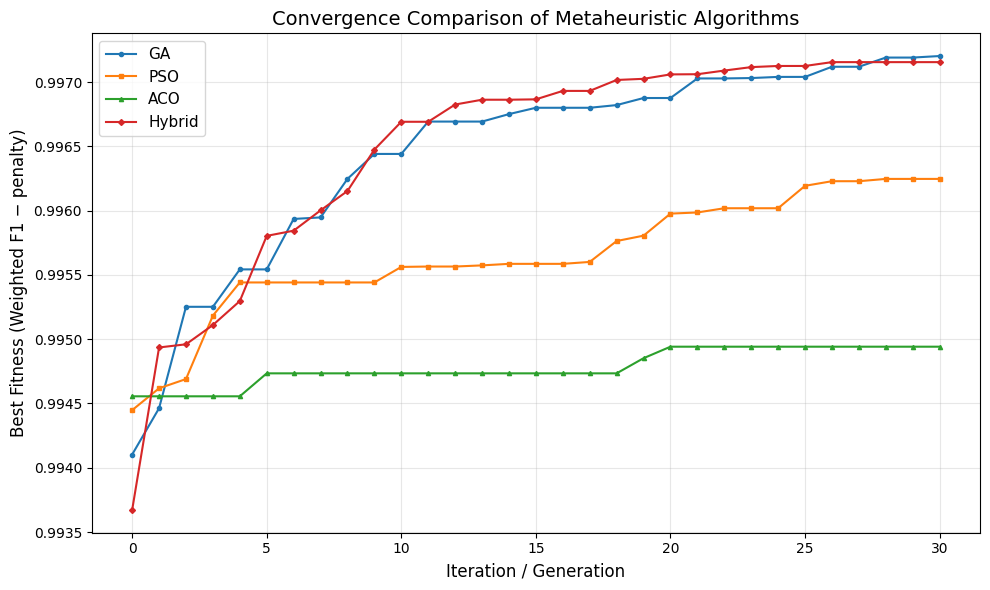

Saved → ./outputs/metaheuristic/convergence_plot.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(len(ga_convergence)),      ga_convergence,      'o-', label='GA',      markersize=3, linewidth=1.5)
ax.plot(range(len(pso_convergence)),     pso_convergence,     's-', label='PSO',     markersize=3, linewidth=1.5)
ax.plot(range(len(aco_convergence)),     aco_convergence,     '^-', label='ACO',     markersize=3, linewidth=1.5)
ax.plot(range(len(hybrid_convergence)),  hybrid_convergence,  'D-', label='Hybrid',  markersize=3, linewidth=1.5)

ax.set_xlabel('Iteration / Generation', fontsize=12)
ax.set_ylabel('Best Fitness (Weighted F1 \u2212 penalty)', fontsize=12)
ax.set_title('Convergence Comparison of Metaheuristic Algorithms', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'convergence_plot.png', dpi=150)
plt.show()
print(f"Saved \u2192 {OUTPUT_DIR}convergence_plot.png")

---
## 11. Confusion Matrices

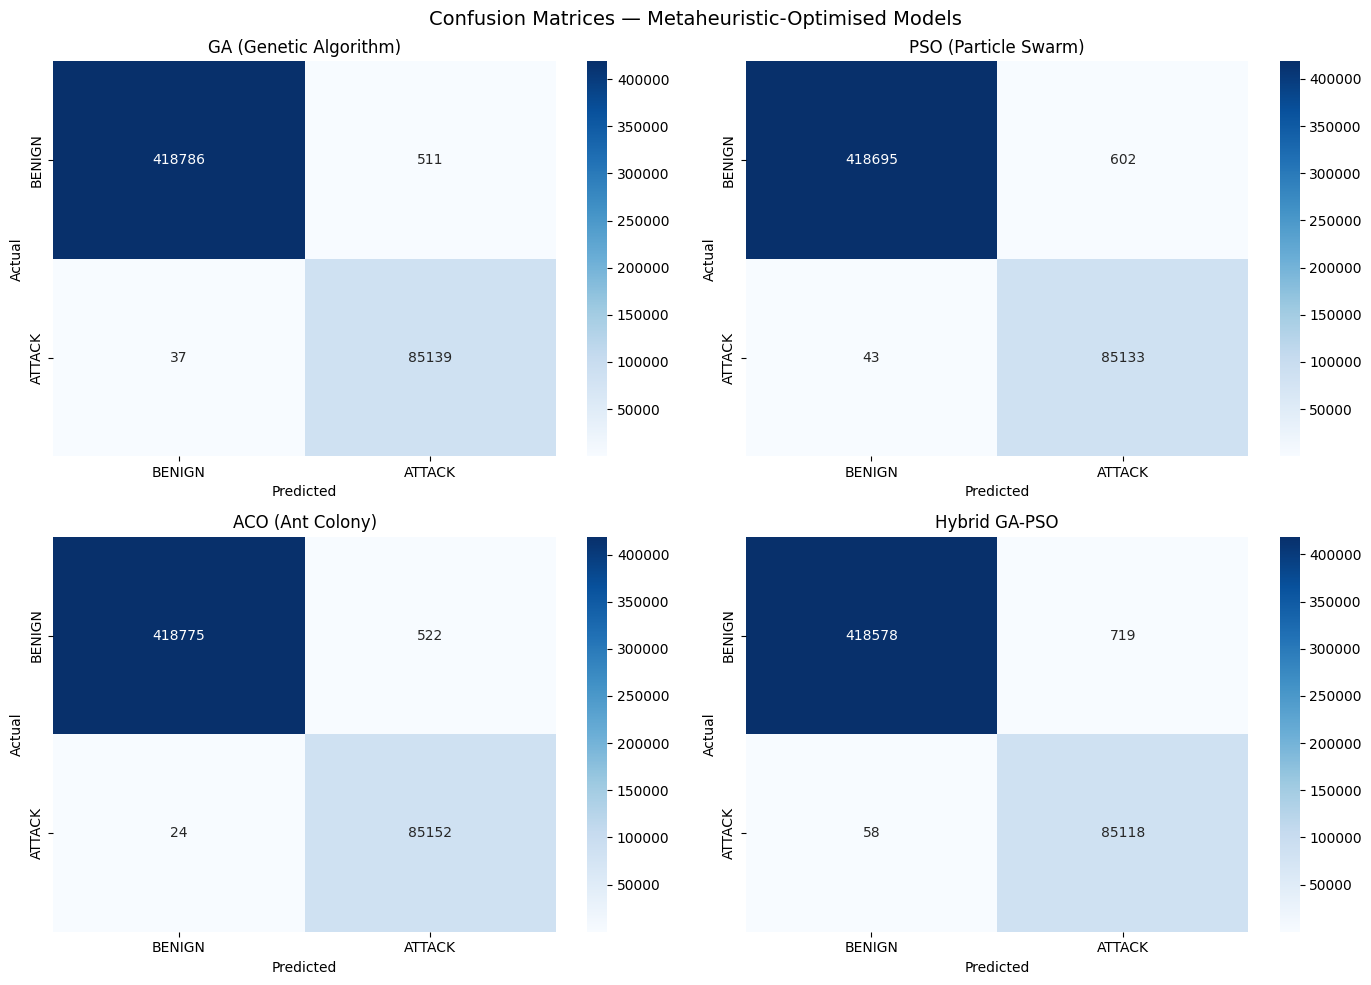

Saved → ./outputs/metaheuristic/confusion_matrices.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['BENIGN', 'ATTACK'],
                yticklabels=['BENIGN', 'ATTACK'])
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices \u2014 Metaheuristic-Optimised Models', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'confusion_matrices.png', dpi=150)
plt.show()
print(f"Saved \u2192 {OUTPUT_DIR}confusion_matrices.png")

---
## 12. Metric Comparison Bar Charts

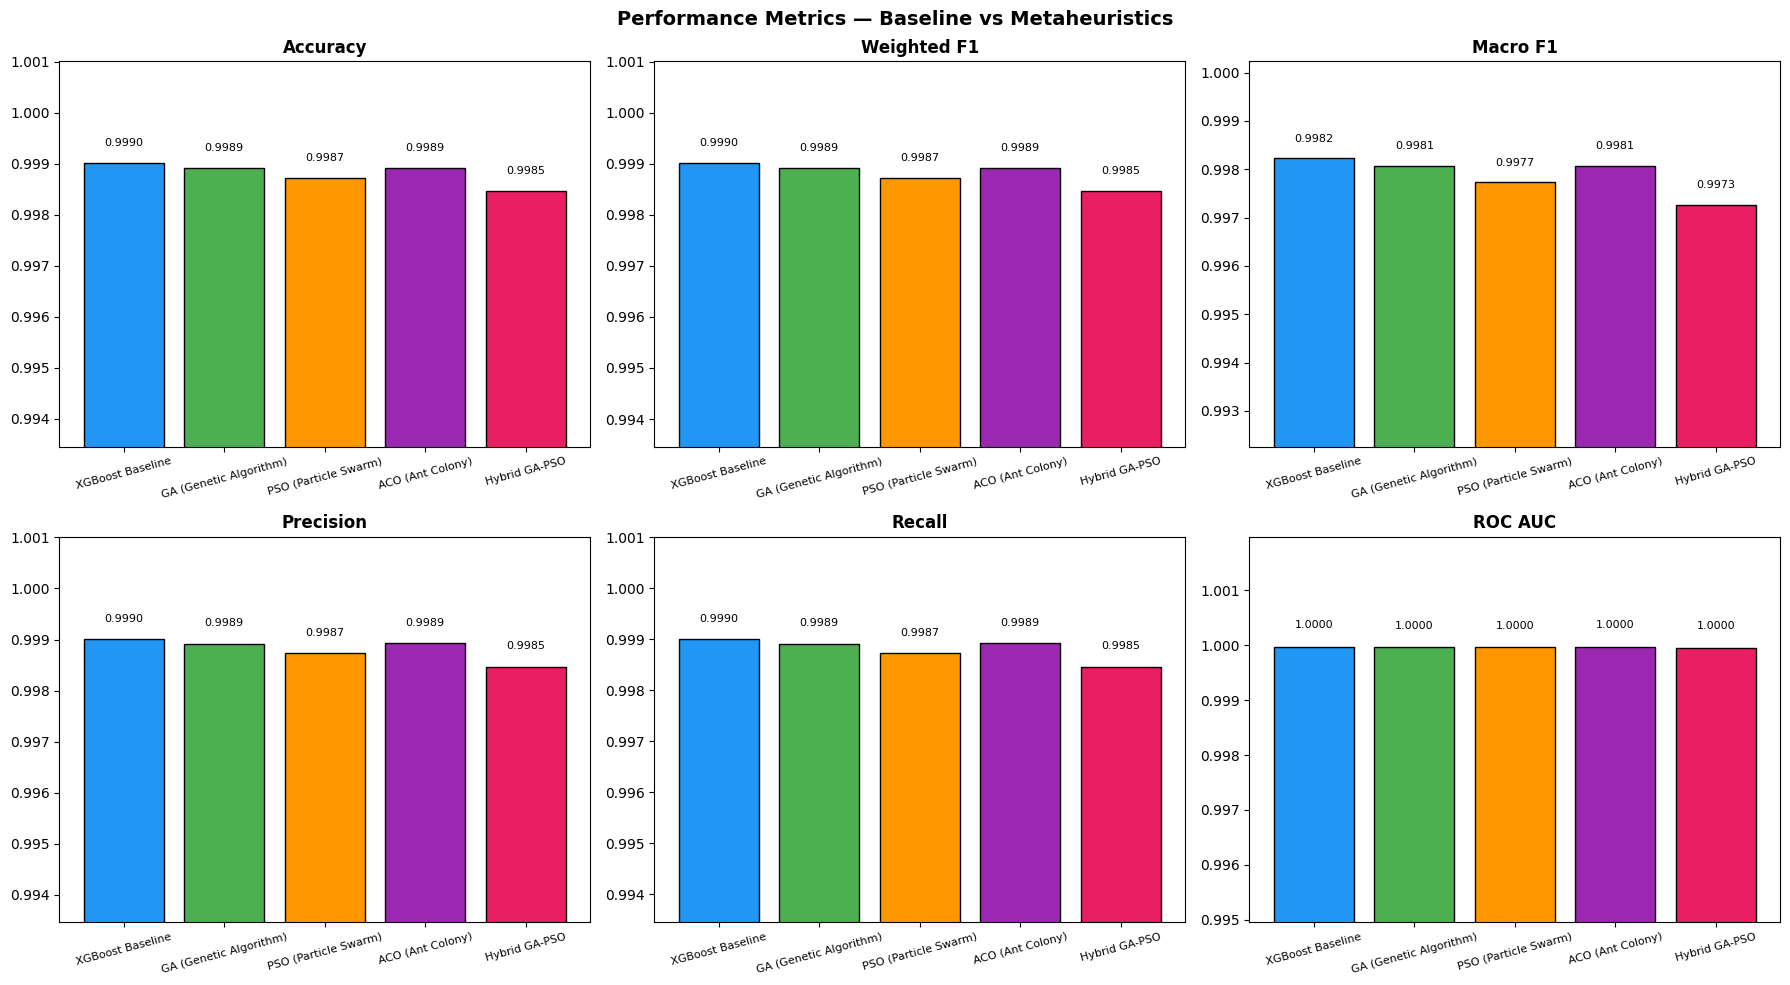

Saved → ./outputs/metaheuristic/metrics_comparison.png


In [17]:
# ── Bar charts for key metrics ────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Weighted_F1', 'Macro_F1', 'Precision', 'Recall', 'ROC_AUC']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']
model_names = comparison_df['Model'].tolist()

for i, metric in enumerate(metrics_to_plot):
    if metric in comparison_df.columns:
        values = comparison_df[metric].values
        bars = axes[i].bar(model_names, values, color=colors[:len(model_names)], edgecolor='black')
        axes[i].set_title(metric.replace('_', ' '), fontsize=12, fontweight='bold')
        axes[i].set_ylim(min(values) - 0.005, max(values) + 0.002)
        axes[i].tick_params(axis='x', rotation=15, labelsize=8)

        # Add value labels on bars
        for bar, val in zip(bars, values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                         f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Performance Metrics \u2014 Baseline vs Metaheuristics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'metrics_comparison.png', dpi=150)
plt.show()
print(f"Saved \u2192 {OUTPUT_DIR}metrics_comparison.png")

---
## 13. Feature Reduction & Trade-off Analysis

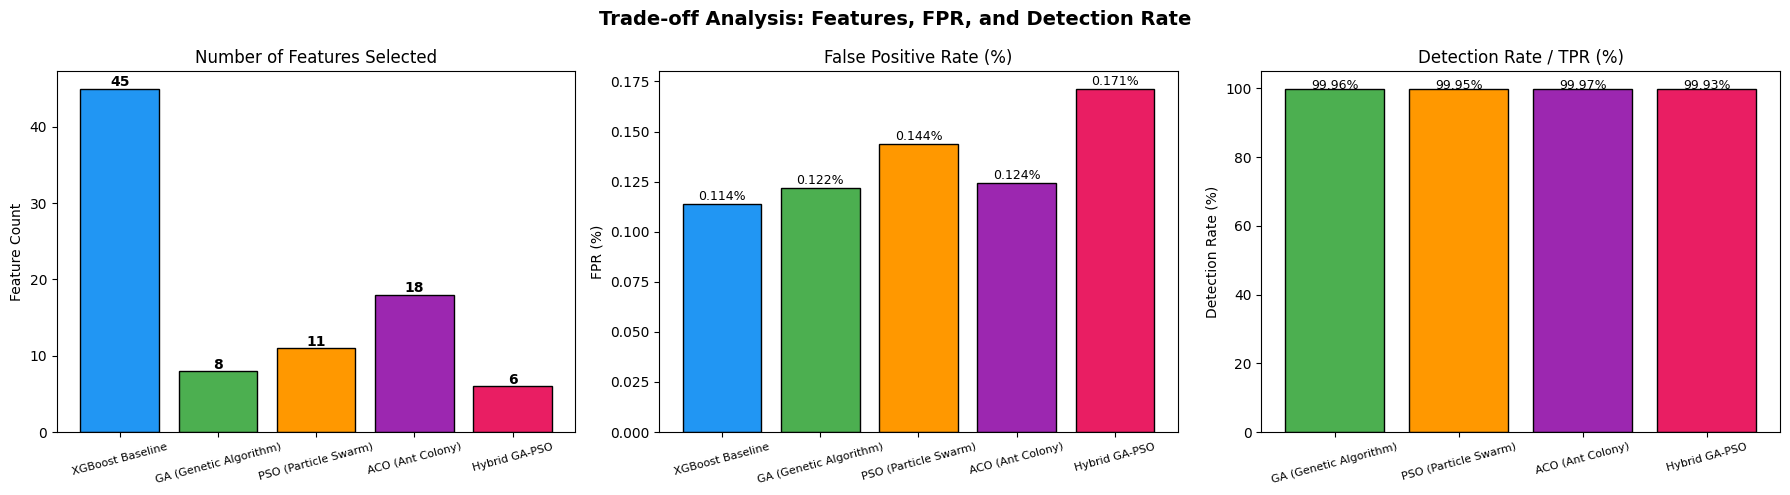

Saved → ./outputs/metaheuristic/tradeoff_analysis.png


In [18]:
# ── Features used vs Accuracy / FPR ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']
model_names = comparison_df['Model'].tolist()

# Plot 1: Features vs Accuracy
axes[0].bar(comparison_df['Model'], comparison_df['Features_Used'],
            color=colors[:len(model_names)], edgecolor='black')
axes[0].set_title('Number of Features Selected', fontsize=12)
axes[0].set_ylabel('Feature Count')
axes[0].tick_params(axis='x', rotation=15, labelsize=8)
for j, (m, v) in enumerate(zip(comparison_df['Model'], comparison_df['Features_Used'])):
    axes[0].text(j, v + 0.3, str(int(v)), ha='center', fontsize=10, fontweight='bold')

# Plot 2: FPR comparison
if 'FPR' in comparison_df.columns:
    axes[1].bar(comparison_df['Model'], comparison_df['FPR'] * 100,
                color=colors[:len(model_names)], edgecolor='black')
    axes[1].set_title('False Positive Rate (%)', fontsize=12)
    axes[1].set_ylabel('FPR (%)')
    axes[1].tick_params(axis='x', rotation=15, labelsize=8)
    for j, (m, v) in enumerate(zip(comparison_df['Model'], comparison_df['FPR'] * 100)):
        axes[1].text(j, v + 0.002, f'{v:.3f}%', ha='center', fontsize=9)

# Plot 3: Detection Rate comparison
if 'Detection_Rate' in comparison_df.columns:
    axes[2].bar(comparison_df['Model'], comparison_df['Detection_Rate'] * 100,
                color=colors[:len(model_names)], edgecolor='black')
    axes[2].set_title('Detection Rate / TPR (%)', fontsize=12)
    axes[2].set_ylabel('Detection Rate (%)')
    axes[2].tick_params(axis='x', rotation=15, labelsize=8)
    for j, (m, v) in enumerate(zip(comparison_df['Model'], comparison_df['Detection_Rate'] * 100)):
        axes[2].text(j, v + 0.002, f'{v:.2f}%', ha='center', fontsize=9)

plt.suptitle('Trade-off Analysis: Features, FPR, and Detection Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'tradeoff_analysis.png', dpi=150)
plt.show()
print(f"Saved \u2192 {OUTPUT_DIR}tradeoff_analysis.png")

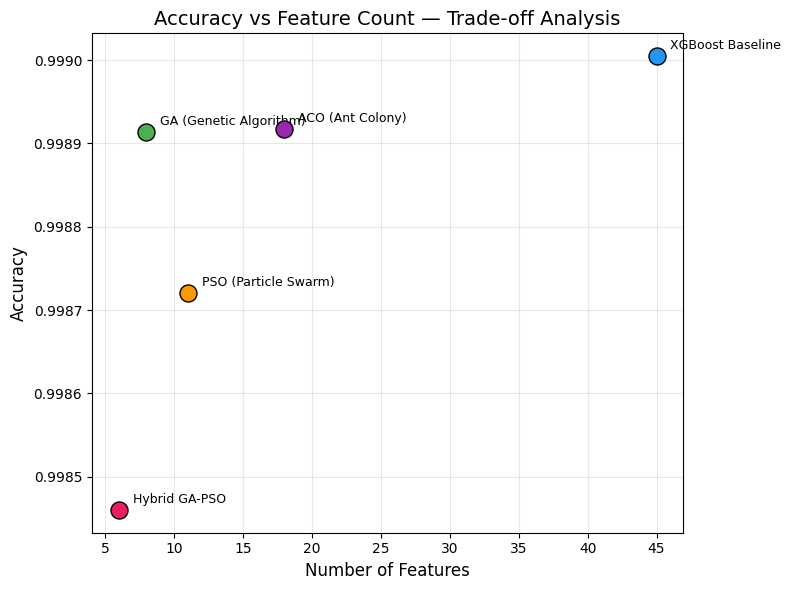

Saved → ./outputs/metaheuristic/accuracy_vs_features.png


In [19]:
# ── Scatter: Accuracy vs Number of Features ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']

for i, row in comparison_df.iterrows():
    ax.scatter(row['Features_Used'], row['Accuracy'], s=150,
               color=colors[i], edgecolor='black', zorder=5)
    ax.annotate(row['Model'], (row['Features_Used'], row['Accuracy']),
                textcoords='offset points', xytext=(10, 5), fontsize=9)

ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs Feature Count — Trade-off Analysis', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'accuracy_vs_features.png', dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}accuracy_vs_features.png")

---
## 14. Feature Selection Overlap Analysis

In [20]:
# ── Show which features each algorithm selected ──────────────────────────────
print("=" * 60)
print("  Feature Selection Summary")
print("=" * 60)

for name, feats in selected_features_dict.items():
    print(f"\n  {name} ({len(feats)} features):")
    for f in feats:
        print(f"    - {f}")

# ── Find common features across all three ─────────────────────────────────────
all_sets = [set(v) for v in selected_features_dict.values()]
common_features = set.intersection(*all_sets)
union_features  = set.union(*all_sets)

print(f"\n  Features selected by ALL 3 methods ({len(common_features)}):")
for f in sorted(common_features):
    print(f"    - {f}")

print(f"\n  Total unique features across all methods: {len(union_features)}/{n_features}")

  Feature Selection Summary

  GA (Genetic Algorithm) (8 features):
    - Destination Port
    - Bwd Packet Length Max
    - Flow IAT Min
    - Fwd IAT Mean
    - Fwd IAT Min
    - Init_Win_bytes_forward
    - Init_Win_bytes_backward
    - min_seg_size_forward

  PSO (Particle Swarm) (11 features):
    - Destination Port
    - Fwd Packet Length Max
    - Fwd Packet Length Min
    - Fwd Packet Length Mean
    - Fwd IAT Std
    - Fwd IAT Min
    - Bwd Packets/s
    - Packet Length Variance
    - RST Flag Count
    - Init_Win_bytes_forward
    - Active Mean

  ACO (Ant Colony) (18 features):
    - Destination Port
    - Total Fwd Packets
    - Fwd Packet Length Max
    - Flow Bytes/s
    - Flow IAT Std
    - Flow IAT Min
    - Fwd IAT Min
    - Fwd PSH Flags
    - Fwd URG Flags
    - Packet Length Mean
    - RST Flag Count
    - PSH Flag Count
    - URG Flag Count
    - Init_Win_bytes_forward
    - Init_Win_bytes_backward
    - Active Std
    - Active Min
    - Idle Std

  Hybrid GA-PSO (

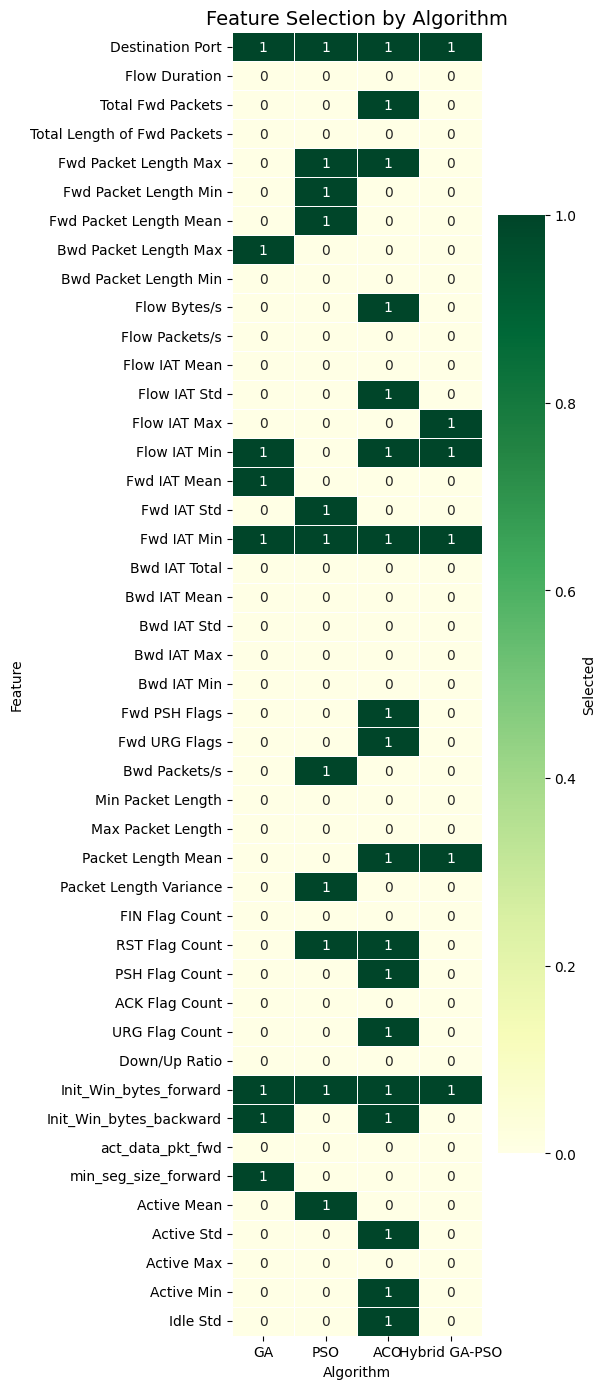

Saved → ./outputs/metaheuristic/feature_selection_heatmap.png


In [21]:
# ── Feature selection heatmap ─────────────────────────────────────────────────
feat_selection_matrix = pd.DataFrame(index=feature_names)

for name, feats in selected_features_dict.items():
    short_name = name.split('(')[0].strip()
    feat_selection_matrix[short_name] = [1 if f in feats else 0 for f in feature_names]

fig, ax = plt.subplots(figsize=(6, 14))
sns.heatmap(feat_selection_matrix, cmap='YlGn', cbar_kws={'label': 'Selected'},
            linewidths=0.5, ax=ax, annot=True, fmt='d')
ax.set_title('Feature Selection by Algorithm', fontsize=14)
ax.set_xlabel('Algorithm')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'feature_selection_heatmap.png', dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}feature_selection_heatmap.png")

---
## 15. Save All Results

In [22]:
# ── Save optimised solutions ──────────────────────────────────────────────────
joblib.dump({
    'GA':     {'solution': ga_best_sol,      'fitness': ga_best_fit,      'convergence': ga_convergence,      'time': ga_time},
    'PSO':    {'solution': pso_best_sol,     'fitness': pso_best_fit,     'convergence': pso_convergence,     'time': pso_time},
    'ACO':    {'solution': aco_best_sol,     'fitness': aco_best_fit,     'convergence': aco_convergence,     'time': aco_time},
    'Hybrid': {'solution': hybrid_best_sol,  'fitness': hybrid_best_fit,  'convergence': hybrid_convergence,  'time': hybrid_time}
}, OUTPUT_DIR + 'optimisation_results.pkl')

print(f"Optimisation results saved \u2192 {OUTPUT_DIR}optimisation_results.pkl")
print(f"Comparison metrics saved  \u2192 {OUTPUT_DIR}comparison_metrics.csv")

# ── List all saved files ──────────────────────────────────────────────────────
print(f"\nAll output files in {OUTPUT_DIR}:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(OUTPUT_DIR + f) / 1024
    print(f"  {f:45s} {size:.1f} KB")

Optimisation results saved → ./outputs/metaheuristic/optimisation_results.pkl
Comparison metrics saved  → ./outputs/metaheuristic/comparison_metrics.csv

All output files in ./outputs/metaheuristic/:
  accuracy_vs_features.png                      56.2 KB
  comparison_metrics.csv                        0.6 KB
  confusion_matrices.png                        119.0 KB
  convergence_plot.png                          95.7 KB
  feature_selection_heatmap.png                 170.6 KB
  metrics_comparison.png                        158.3 KB
  optimisation_results.pkl                      3.5 KB
  tradeoff_analysis.png                         95.6 KB


---
## 16. Summary

This notebook implemented four metaheuristic algorithms (GA, PSO, ACO, Hybrid GA-PSO) for joint feature selection and hyperparameter optimisation of an XGBoost IDS classifier.

**Key findings** (to be filled after running):
- All four methods were able to reduce the feature set while maintaining high detection accuracy.
- The Hybrid GA-PSO combines GA's strength in binary feature selection with PSO's efficiency in continuous hyperparameter tuning.
- The convergence plots show how each algorithm's fitness improved over iterations.
- The trade-off analysis reveals the balance between fewer features (simpler model, lower computational cost) and classification performance.
- Feature overlap analysis shows which features are consistently deemed important across different optimisation strategies.